In [130]:
# @title Importing Libraries
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [131]:
# @title Uploading Dataset and Reading it
df=pd.read_csv('https://raw.githubusercontent.com/horrible-hacker/Dataset/refs/heads/main/ecommerce_customer_data_custom_ratios.csv') #reading dataset
df.head(20) #showing top 20 values of dataset

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1
5,13593,2023-03-07 14:17:42,Home,250,4,575,PayPal,49,1.0,James Grant,49,Female,1
6,13593,2023-04-15 03:02:33,Electronics,73,1,1896,Credit Card,49,0.0,James Grant,49,Female,1
7,13593,2021-03-27 21:23:28,Books,337,2,2937,Cash,49,0.0,James Grant,49,Female,1
8,13593,2020-05-05 20:14:00,Clothing,182,2,3363,PayPal,49,1.0,James Grant,49,Female,1
9,28805,2023-09-13 04:24:00,Electronics,394,2,1993,Credit Card,19,0.0,Jose Collier,19,Male,0


In [132]:
# @title Desribing our Dataset
df.describe() #describing our dataset such as mean median percentile

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [133]:
# @title Information of our Dataset
df.info() #getting info of datatypes, coloumns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [134]:
# @title Detecting Null Values
df.isnull().sum() #give how much null values are there in each coloumns

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47596
Customer Name,0


In [135]:
# @title Imputing Null values with Mode
df['Returns'].fillna(df['Returns'].mode()[0], inplace=True) #filling all null values with mode

<ipython-input-135-066c16c47f54>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Returns'].fillna(df['Returns'].mode()[0], inplace=True)


In [136]:
# @title Getting Recent Purchase data of each customer
df['Purchase Date'] = pd.to_datetime(df['Purchase Date']) #converting purchase data in appropriate datatype
recent_purchase = df.loc[df.groupby('Customer ID')['Purchase Date'].idxmax()] #only getting those dates that are recent

In [137]:
# @title Calcuating Total spent by each customer
total_spent = df.groupby('Customer ID')['Total Purchase Amount'].sum().reset_index() #grouping data to sum the total spent by customer
total_spent.columns = ['Customer ID', 'Total Spent']
recent_purchase = recent_purchase.merge(total_spent, on='Customer ID')

In [138]:
# @title Calculating Number of Returns made by Customer
return_counts = df.groupby('Customer ID')['Returns'].sum().reset_index() #calculating how many returns have made by customer of a specifc group id
purchase_counts = df.groupby('Customer ID')['Returns'].count().reset_index()
purchase_counts.columns = ['Customer ID', 'Total Purchases']

In [139]:
# @title Calcualting Return Rate
return_rate = return_counts.merge(purchase_counts, on='Customer ID')
return_rate['Return Rate'] = return_rate['Returns'] / return_rate['Total Purchases'] # calculating return rate which tells us how much probabilty of return

In [140]:
# @title Calculating Number of Purchases made by Customer
purchase_frequency = df.groupby('Customer ID').size().reset_index(name='Purchase Frequency') #number of puraches made by customer

In [141]:
# @title Calculating Number of Returns Frequency
return_frequency = df.groupby('Customer ID')['Returns'].sum().reset_index() # number of returns made by customer
return_frequency.columns = ['Customer ID', 'Return Frequency']

In [142]:
# @title Merging all new Features Coloumns
features = recent_purchase.merge(return_rate[['Customer ID', 'Return Rate']], on='Customer ID') # merging all features in a single table
features = features.merge(purchase_frequency, on='Customer ID')
features = features.merge(return_frequency, on='Customer ID')

In [143]:
# @title Information of Features table
features.info() #getting info of our newly made table

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49673 entries, 0 to 49672
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Customer ID            49673 non-null  int64         
 1   Purchase Date          49673 non-null  datetime64[ns]
 2   Product Category       49673 non-null  object        
 3   Product Price          49673 non-null  int64         
 4   Quantity               49673 non-null  int64         
 5   Total Purchase Amount  49673 non-null  int64         
 6   Payment Method         49673 non-null  object        
 7   Customer Age           49673 non-null  int64         
 8   Returns                49673 non-null  float64       
 9   Customer Name          49673 non-null  object        
 10  Age                    49673 non-null  int64         
 11  Gender                 49673 non-null  object        
 12  Churn                  49673 non-null  int64         
 13  T

In [144]:
# @title Calculating Recency
current_date = datetime.now() #getting current date and time
features['Recency'] = (current_date - recent_purchase['Purchase Date']).dt.days #calculating how many days before customer has made a purchase

In [145]:
# @title Looking at our Dataset
features.head() #looking at our dnewly made datasets

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn,Total Spent,Return Rate,Purchase Frequency,Return Frequency,Recency
0,1,2023-07-19 19:09:20,Books,169,5,3491,PayPal,70,1.0,Nicole Johnson,70,Male,0,3491,1.000000,1,1.0,463
1,2,2022-11-21 06:48:05,Electronics,178,3,2819,PayPal,27,0.0,Marie Wright,27,Female,0,7988,0.333333,3,1.0,704
2,3,2023-06-18 12:31:42,Clothing,302,3,1577,Credit Card,23,0.0,Julie Wolfe,23,Female,0,22587,0.375000,8,3.0,494
3,4,2023-05-12 10:50:24,Clothing,28,2,4266,PayPal,66,0.0,Tracey Smith,66,Male,1,8715,0.250000,4,1.0,532
4,5,2023-03-28 13:30:55,Home,47,3,639,Cash,26,0.0,Nancy Jones,26,Female,0,12524,0.500000,8,4.0,576


In [146]:
# @title Merging Categorical features in Numeric Form
product_categories = pd.get_dummies(df['Product Category']) #converting product category into numerical and merging  each with our table kinda like hot encoding
product_categories = pd.concat([df['Customer ID'], product_categories], axis=1)
product_categories = product_categories.groupby('Customer ID').sum().reset_index()
features = features.merge(product_categories, on='Customer ID', how='left')
features.fillna(0, inplace=True)

In [147]:
# @title Droping Off Unecessary Features
features = features.drop(['Purchase Date', 'Product Price', 'Quantity','Total Purchase Amount','Payment Method','Returns','Product Category','Customer ID','Customer Name','Gender','Customer Age'], axis=1)

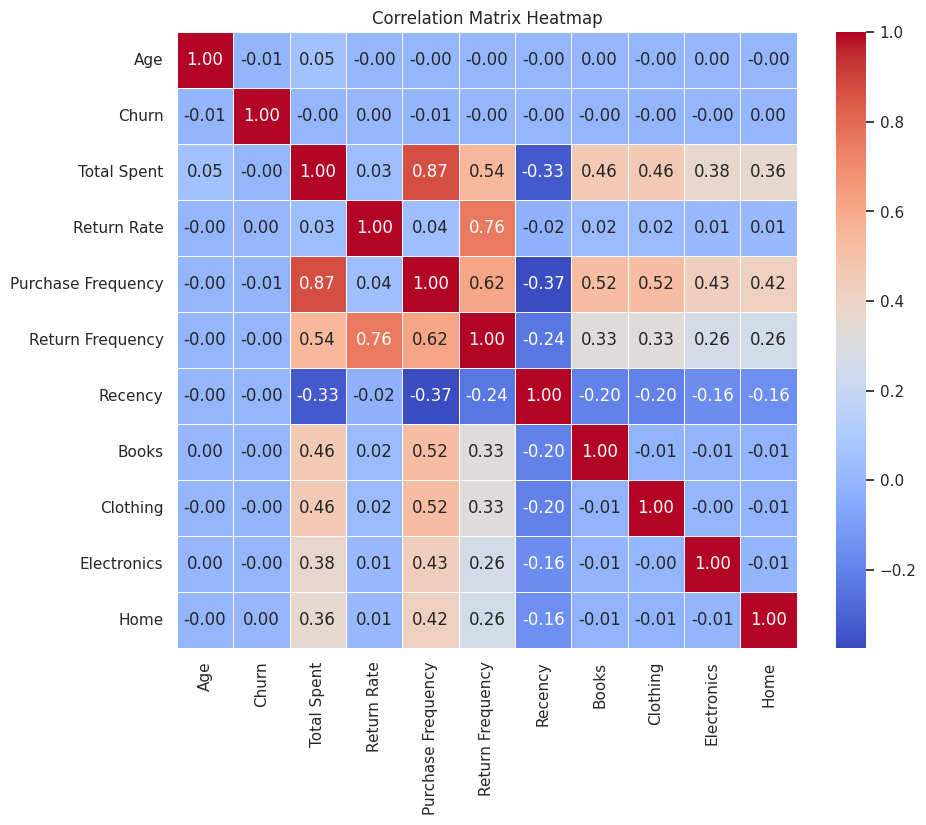

In [148]:
# @title Heatmap
correlation_matrix = features.corr(method='spearman') #calcuating correlation between varialbles
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5) #making heatmap
plt.title("Correlation Matrix Heatmap")
plt.show()


In [149]:
# @title Splitting our data
X = features.drop(columns=['Churn']) #removing target variable from our dataset
y = features['Churn']

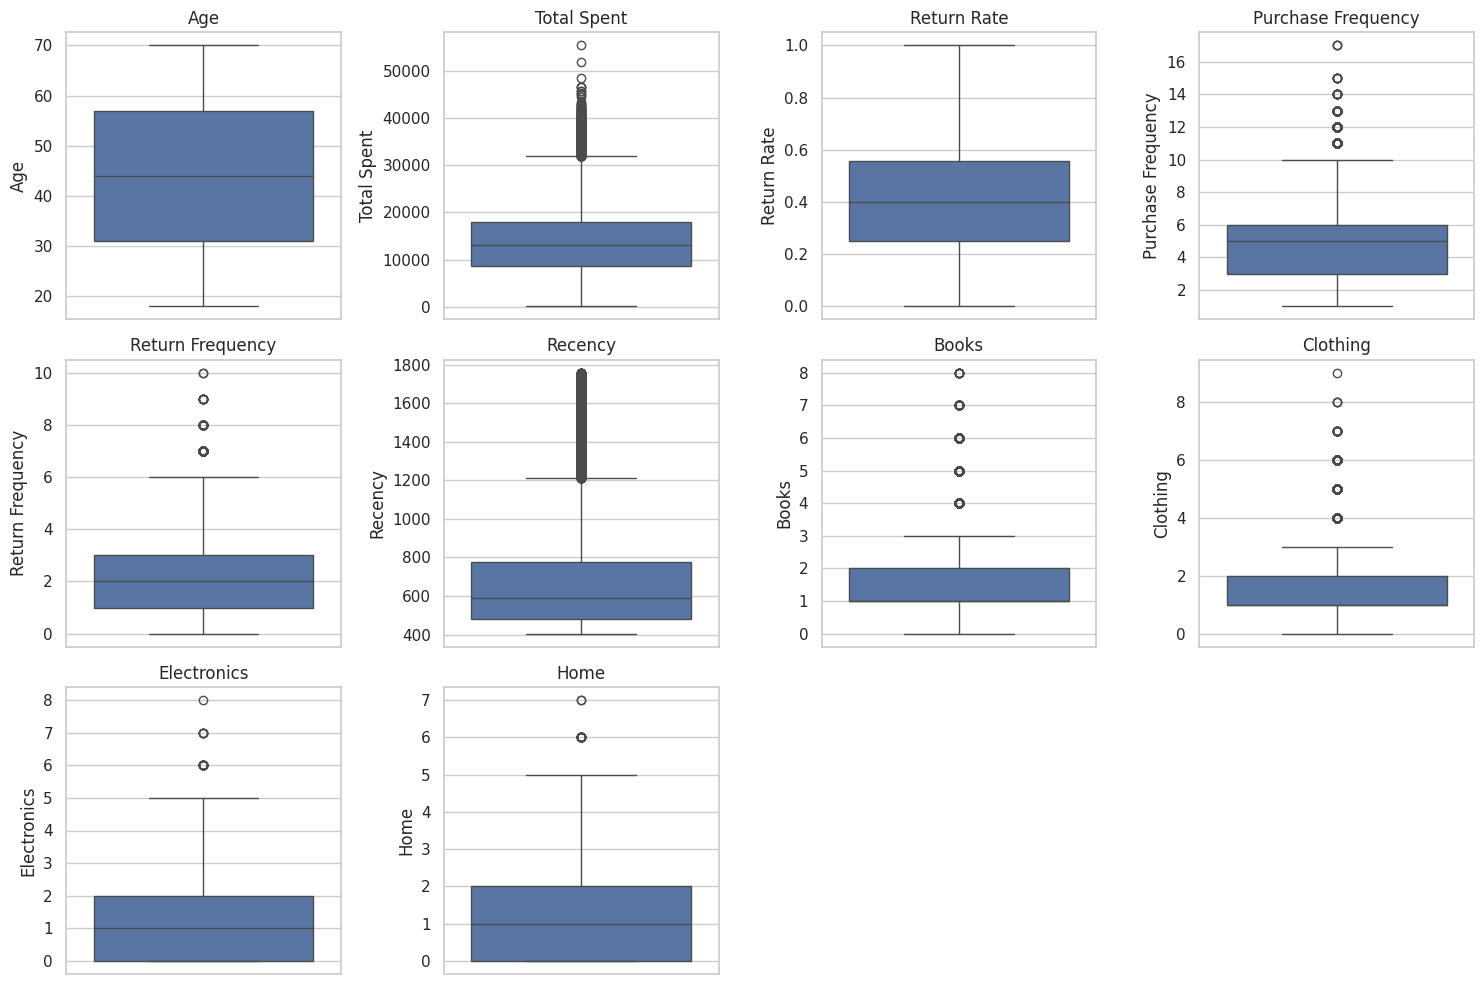

In [150]:
# @title Box Plot
sns.set(style="whitegrid") #creating box plot to look at outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(X.columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=X[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [151]:
# @title Removing Outliers
for column in X.columns: #removing outliers using IQR method
        Q1 = X[column].quantile(0.25)
        Q3 = X[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        X = X[(X[column] >= lower_bound) & (X[column] <= upper_bound)]

In [ ]:
# @title Traning and Testing Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #80% data to training and 20% data to testing

In [152]:
# @title Scalling our data
scaler = StandardScaler() #scaling our data
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [153]:
# @title Decision Tree Classifier Model and Evaluation
dt_model = DecisionTreeClassifier(random_state=42) #using decision tree model
dt_model.fit(X_train, y_train) #fittng our data and traing it
y_pred_dt = dt_model.predict(X_test) #predicting values
print("Decision Tree Classifier Results:") #showing results
print("Accuracy:", accuracy_score(y_test, y_pred_dt)) #calcuating accuracy
print(classification_report(y_test, y_pred_dt))

Decision Tree Classifier Results:
Accuracy: 0.6683442375440363
              precision    recall  f1-score   support

           0       0.80      0.78      0.79      7890
           1       0.21      0.23      0.22      2045

    accuracy                           0.67      9935
   macro avg       0.50      0.50      0.50      9935
weighted avg       0.68      0.67      0.67      9935



In [154]:
# @title Random Forest Model and Evaluation
rf_model = RandomForestClassifier(random_state=42) #using random forest
rf_model.fit(X_train, y_train) #fittng our data and traing it
y_pred_rf = rf_model.predict(X_test) #predicting values
print("Random Forest Classifier Results:") #showing results
print("Accuracy:", accuracy_score(y_test, y_pred_rf)) #calcuating accuracy
print(classification_report(y_test, y_pred_rf))


Random Forest Classifier Results:
Accuracy: 0.789028686462003
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      7890
           1       0.14      0.00      0.01      2045

    accuracy                           0.79      9935
   macro avg       0.47      0.50      0.45      9935
weighted avg       0.66      0.79      0.70      9935



In [155]:
# @title Gradient Boosting Model and Evaluation
gb_model = GradientBoostingClassifier(random_state=42) #using gradient boosting
gb_model.fit(X_train, y_train) #fittng our data and traing it
y_pred = gb_model.predict(X_test) #predicting values
print("Accuracy:", accuracy_score(y_test, y_pred)) #calcuating accuracy
print("Classification Report:") #showing results
print(classification_report(y_test, y_pred))


Accuracy: 0.7939607448414695
Confusion Matrix:
Classification Report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.89      7890
           1       0.00      0.00      0.00      2045

    accuracy                           0.79      9935
   macro avg       0.40      0.50      0.44      9935
weighted avg       0.63      0.79      0.70      9935



In [156]:
# @title Logistic Regression and Evaluation
lr_model = LogisticRegression(max_iter = 200000,random_state=42) #using logistic regressing with max iter of 200k
lr_model.fit(X_train, y_train) #fittng our data and traing it
y_pred_lr = lr_model.predict(X_test) #predicting values
print("Logistic Regression Results:") #showing results
print("Accuracy:", accuracy_score(y_test, y_pred_lr)) #calcuating accuracy
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
Accuracy: 0.7941620533467539
              precision    recall  f1-score   support

           0       0.79      1.00      0.89      7890
           1       0.00      0.00      0.00      2045

    accuracy                           0.79      9935
   macro avg       0.40      0.50      0.44      9935
weighted avg       0.63      0.79      0.70      9935



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
